# Recherche d'un modele pour X_t (modele virus4)
Suite du notebook principal : on cherche un modele pour le virus reconstruit.
Toutes les figures sont ecrites dans `figures_local/`.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as scs
os.makedirs('figures_local', exist_ok=True)

d = np.loadtxt('virus4_Xt.csv', delimiter=',', skiprows=1)
t, X = d[:, 0], d[:, 1]
dt = np.median(np.diff(t))
dX = np.diff(X)
L = len(X)
rng = np.random.default_rng(0)

## Deux signatures des increments natifs : queues lourdes et correlation

In [2]:
kurt = scs.kurtosis(dX)        # exces de kurtosis (0 si gaussien)
acf1 = np.corrcoef(dX[:-1], dX[1:])[0, 1]
print('exces de kurtosis =', round(kurt, 2))
print('autocorrelation lag 1 =', round(acf1, 2))
print('p-value normalite (ks_1samp) =', scs.kstest((dX - dX.mean()) / dX.std(), 'norm').pvalue)

exces de kurtosis = 3.33
autocorrelation lag 1 = 0.26
p-value normalite (ks_1samp) = 6.117762529048834e-14


## Le test sur les niveaux ne discrimine pas (sur-puissance)

In [3]:
# brownien standard = somme cumulee d'increments gaussiens de variance pas
def brownien(n, pas):
    return np.concatenate([[0.0], np.cumsum(rng.normal(0, np.sqrt(pas), n - 1))])

# OU par sa solution exacte (integrale d'Ito approchee par une somme)
def simule_ou(tt, pas, theta, mu, sigma, x0=0.0):
    B = brownien(len(tt), pas)
    dB = np.diff(B)
    ito = np.concatenate([[0.0], np.cumsum(np.exp(theta * tt[:-1]) * dB)])
    return mu + (x0 - mu) * np.exp(-theta * tt) + sigma * np.exp(-theta * tt) * ito

# meme modele compare a lui-meme : ks_2samp sur les niveaux
ref = simule_ou(t, dt, 0.07, -0.66, dX.std() / np.sqrt(dt))
ps = [scs.ks_2samp(simule_ou(t, dt, 0.07, -0.66, dX.std() / np.sqrt(dt)), ref).pvalue
      for _ in range(200)]
print('OU vs lui-meme, p-value moyenne sur les niveaux =', np.mean(ps))

OU vs lui-meme, p-value moyenne sur les niveaux = 2.6542988192382065e-10


## Lois a queues lourdes au pas natif

In [4]:
# Lois a queues lourdes ajustees sur les increments natifs (ks_2samp, p-value moyenne)
import warnings; warnings.filterwarnings('ignore')
m, s = dX.mean(), dX.std()
def meanp_incr(draw, N=300):
    return np.mean([scs.ks_2samp(draw(), dX).pvalue for _ in range(N)])
res = {}
res['gaussienne'] = meanp_incr(lambda: rng.normal(m, s, len(dX)))
res['Laplace'] = meanp_incr(lambda: scs.laplace(m, s / np.sqrt(2)).rvs(len(dX)))
a = 3 / scs.kurtosis(dX)  # melange normal-Gamma : exces de kurtosis = 3/a
def gamma_mix():
    W = rng.gamma(a, 1.0 / a, len(dX))
    return m + s * np.sqrt(W) * rng.standard_normal(len(dX))
res['melange normal-Gamma'] = meanp_incr(gamma_mix)
for nom, v in res.items():
    print('%-22s mean-p = %.4f' % (nom, v))

gaussienne             mean-p = 0.0000
Laplace                mean-p = 0.0011
melange normal-Gamma   mean-p = 0.0016


## Coarse-graining : les queues sont une structure de haute frequence

k= 1 dt=0.015 n=1998 kurt= 3.33 mean-p(gauss)=0.000


k= 2 dt=0.030 n= 999 kurt= 1.56 mean-p(gauss)=0.149
k= 3 dt=0.045 n= 666 kurt= 0.95 mean-p(gauss)=0.587


k= 5 dt=0.075 n= 399 kurt= 0.65 mean-p(gauss)=0.426
k= 8 dt=0.120 n= 249 kurt=-0.18 mean-p(gauss)=0.659


k=12 dt=0.180 n= 166 kurt=-0.01 mean-p(gauss)=0.626
k=20 dt=0.300 n=  99 kurt= 0.60 mean-p(gauss)=0.680


k=30 dt=0.450 n=  66 kurt= 0.25 mean-p(gauss)=0.727


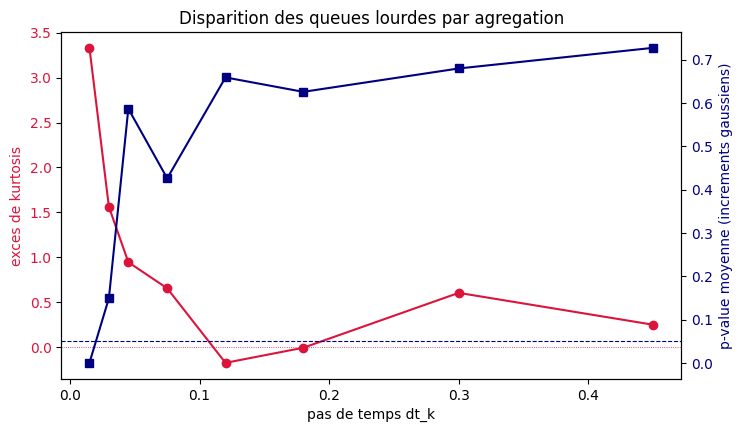

In [5]:
ks = [1, 2, 3, 5, 8, 12, 20, 30]
dtk_list, kurt_list, mp_list = [], [], []
for k in ks:
    Xk = X[::k]
    dXk = np.diff(Xk)
    nk = len(dXk)
    mk, sk = dXk.mean(), dXk.std()
    mp = np.mean([scs.ks_2samp(rng.normal(mk, sk, nk), dXk).pvalue for _ in range(300)])
    dtk_list.append(dt * k); kurt_list.append(scs.kurtosis(dXk)); mp_list.append(mp)
    print('k=%2d dt=%.3f n=%4d kurt=%5.2f mean-p(gauss)=%.3f' % (k, dt*k, nk, kurt_list[-1], mp))

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(dtk_list, kurt_list, 'o-', color='crimson')
ax1.axhline(0, color='crimson', lw=0.6, ls=':')
ax1.set_xlabel('pas de temps dt_k'); ax1.set_ylabel('exces de kurtosis', color='crimson')
ax1.tick_params(axis='y', labelcolor='crimson')
ax2 = ax1.twinx()
ax2.plot(dtk_list, mp_list, 's-', color='navy')
ax2.axhline(0.05, color='navy', lw=0.8, ls='--')
ax2.set_ylabel('p-value moyenne (increments gaussiens)', color='navy')
ax2.tick_params(axis='y', labelcolor='navy')
plt.title('Disparition des queues lourdes par agregation')
plt.savefig('figures_local/recherche_coarsegrain.png', dpi=150, bbox_inches='tight')
plt.show()

## Test du modele au pas grossier (Ornstein-Uhlenbeck)

OU grossier : theta=0.078 mu=-0.627 sigma=0.0601


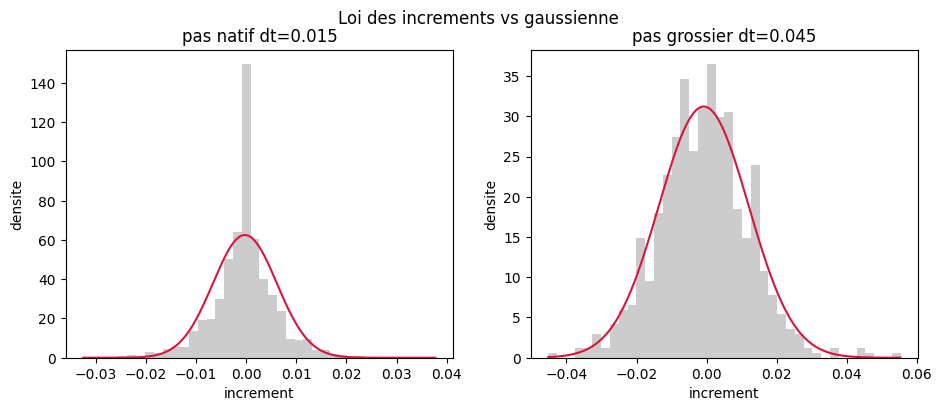

In [6]:
k = 3
tk, Xk = t[::k], X[::k]
dtk = dt * k
dXk = np.diff(Xk)
nk = len(dXk)
# estimation OU : regression de dX sur X
A = np.vstack([np.ones(nk), Xk[:-1]]).T
coef, *_ = np.linalg.lstsq(A, dXk, rcond=None)
b0, b1 = coef
theta = -b1 / dtk
mu = b0 / (theta * dtk)
sigma = (dXk - A @ coef).std() / np.sqrt(dtk)
print('OU grossier : theta=%.3f mu=%.3f sigma=%.4f' % (theta, mu, sigma))

mk, sk = dX.mean(), dX.std()
mkc, skc = dXk.mean(), dXk.std()
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, data, mm, ss, lab in [(ax[0], dX, mk, sk, 'pas natif dt=%.3f' % dt),
                             (ax[1], dXk, mkc, skc, 'pas grossier dt=%.3f' % dtk)]:
    a.hist(data, bins=40, density=True, color='0.8')
    g = np.linspace(data.min(), data.max(), 300)
    a.plot(g, scs.norm(mm, ss).pdf(g), color='crimson')
    a.set_title(lab); a.set_xlabel('increment'); a.set_ylabel('densite')
plt.suptitle('Loi des increments vs gaussienne')
plt.savefig('figures_local/recherche_increments.png', dpi=150, bbox_inches='tight')
plt.show()

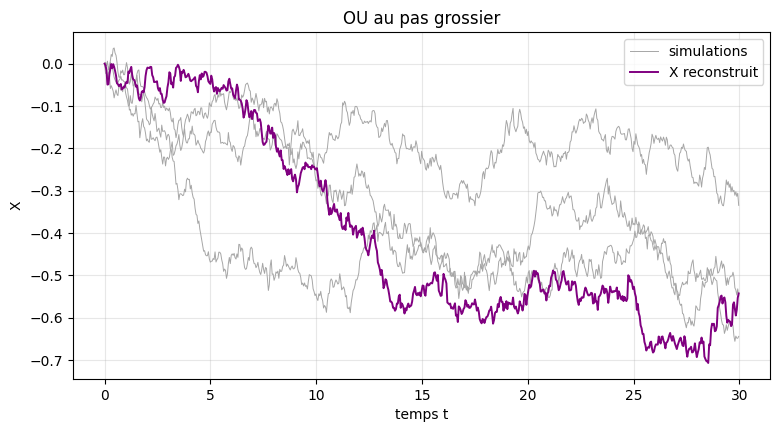

In [7]:
# support visuel : quelques trajectoires OU au pas grossier vs X reconstruit
plt.figure(figsize=(9, 4.5))
for j in range(3):
    plt.plot(tk, simule_ou(tk, dtk, theta, mu, sigma), color='0.65', lw=0.7,
             label='simulations' if j == 0 else None)
plt.plot(tk, Xk, color='purple', lw=1.4, label='X reconstruit')
plt.xlabel('temps t'); plt.ylabel('X'); plt.title('OU au pas grossier'); plt.legend(); plt.grid(alpha=0.3)
plt.savefig('figures_local/recherche_sim_ou.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# p-value du test : ks_2samp sur les increments grossiers
def incr_ou():
    return np.diff(simule_ou(tk, dtk, theta, mu, sigma))
def incr_gauss():
    return rng.normal(mkc, skc, nk)
mp_ou = np.mean([scs.ks_2samp(incr_ou(), dXk).pvalue for _ in range(400)])
mp_g = np.mean([scs.ks_2samp(incr_gauss(), dXk).pvalue for _ in range(400)])
print('p-value moyenne (increments OU)      =', round(mp_ou, 3))
print('p-value moyenne (increments gaussiens) =', round(mp_g, 3))

p-value moyenne (increments OU)      = 0.716
p-value moyenne (increments gaussiens) = 0.58
